In [8]:
import torch
import torch.nn as nn 
from torch.func import jacrev
from torch.func import vmap
import casadi as cs
from casadi import cos, sin

import numpy as np
import matplotlib.pyplot as plt 
from scipy.integrate import solve_ivp

plt.rcParams["figure.figsize"] = (10, 8)

device = 'cuda'

In [5]:
# Piecewise constant control using expanded commands
# used for save and generate the constant command over the interval 

class ExpandedControl:
    def __init__(self, expanded_time, expanded_commands):
        self.expanded_time = expanded_time
        self.expanded_commands = expanded_commands

    def __call__(self, t):
        idx = np.searchsorted(self.expanded_time, t, side='right') - 1
        idx = np.clip(idx, 0, len(self.expanded_commands) - 1)
        return self.expanded_commands[idx]

In [19]:
#@ Pinn-C dataset (with control input)

time_range = [0.0, 20.0]
time_points = np.linspace(time_range[0], time_range[1], 1000)

commands = np.zeros((len(time_points), 4))
# smooth input 
commands[:, 0] = 0.5* np.random.rand(time_points.shape[0])
commands[:, 1] = 0.1 * np.sin(0.5 * time_points) - np.cos(0.1 * time_points)
commands[:, 2] = 0.5* np.random.rand(time_points.shape[0])
commands[:, 3] = 0.1 * np.cos(0.5 * time_points)


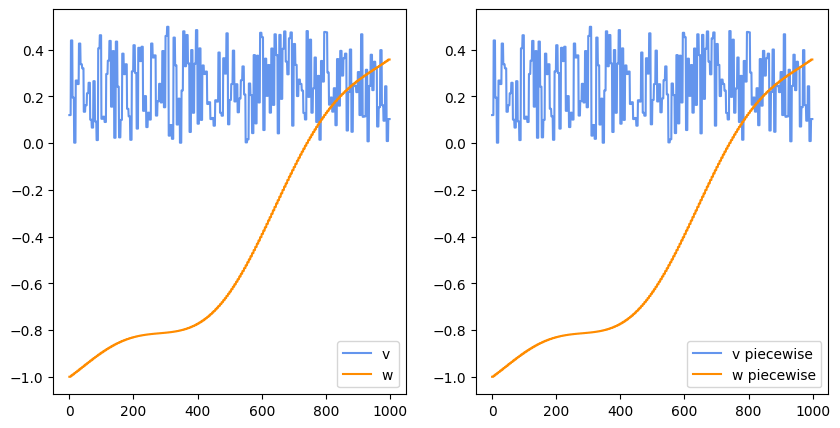

In [17]:
# downsample the commands: constant for each 5 timestep
# 1 timestep = 20.0 sec / 1000 time_step = 0.02 sec

delta_t = 5
T_max = delta_t * 0.02 
for i in range(0, len(time_points), delta_t):
    commands[i:i+delta_t, 0] = commands[i, 0]
    commands[i:i+delta_t, 1] = commands[i, 1]

fig, axs = plt.subplots(1,2)


axs[0].plot(commands[:, 0], color="cornflowerblue", label='v')
axs[0].plot(commands[:, 1], color="darkorange", label='w')
control = ExpandedControl(time_points, expanded_commands=commands)
axs[1].plot(control(time_points)[:, 0], color="cornflowerblue", label='v piecewise')
axs[1].plot(control(time_points)[:, 1], color="darkorange", label='w piecewise')
axs[0].legend()
axs[1].legend()
fig.set_figheight(5)
fig.set_figwidth(10)
plt.show()

**Quadrotor model parameters** (crazyflie)**:**

* mass: 0.028
* arm_length: 0.044
* Ixx: 2.3951e-5
* Iyy: 2.3951e-5
* Izz: 3.2347e-5
* cm: 2.4e-6
* tau: 0.08

In [20]:
# Simplified Dynamic Model of the Quadrotor
def dyna_quadrotor(t, state, control, gravity=9.80665, mass=0.028):
    # state: [px,py,pz, vx,vy,vz, roll,pitch,yaw]
    pos_x = state[0]
    pos_y = state[1]
    pos_z = state[2]
    vx = state[3]
    vy = state[4]
    vz = state[5]
    roll = state[6]
    pitch = state[7]
    yaw = state[8]
    # control: [tau_roll,tau_pitch,tau_yaw, thrust]
    u = control(t)
    tau_roll = u[0]
    tau_pitch = u[1]
    tau_yaw = u[2]
    thrust = u[3]
    
    RotMatrix = cs.vertcat( # Rotation Matrix RPY (XYZ)
        cs.horzcat(cos(pitch)*cos(yaw), sin(roll)*sin(pitch)*cos(yaw) - cos(roll)*sin(yaw), cos(roll)*sin(pitch)*cos(yaw) + sin(roll)*sin(yaw)),
        cs.horzcat(cos(pitch)*sin(yaw), sin(roll)*sin(pitch)*sin(yaw) + cos(roll)*cos(yaw), cos(roll)*sin(pitch)*sin(yaw) - sin(roll)*cos(yaw)),
        cs.horzcat(-sin(pitch), sin(roll)*cos(pitch), cos(roll)*cos(pitch))
    )
    
    state_dot = np.zeros(9)
    
    state_dot[0] = vx # px_dot = vx
    state_dot[1] = vy # py_dot = vy
    state_dot[2] = vz # pz_dot = vz
    
    vdot = vertcat(0.,0.,-gravity) + RotMatrix @ vertcat(0.,0.,thrust/mass)
    
    state_dot[3] = vdot[0]# vx_dot
    state_dot[4] = vdot[1]# vy_dot 
    state_dot[5] = vdot[2]# vz_dot
    
    state_dot[6] = (tau_roll - roll)/tau # roll_dot
    state_dot[7] = (tau_pitch - pitch)/tau # pitch_dot
    state_dot[8] = (tau_yaw - yaw)/tau # yaw_dot

In [ ]:
initial_conditions = np.array([0,0,0, 0,0,0, 0,0,0])

quadorotor_integration = solve_ivp(
    lambda t, x: dyna_quadrotor(t, x, control),
    time_range,
    initial_conditions,
    t_eval=time_points,
)

t_values = unikin_integration.t
trajectory = unikin_integration.y

In [ ]:
#@ Plot results
# Plot trajectory
plt.figure(figsize=(10, 5))
plt.plot(trajectory[0], trajectory[1], label="Trajectory")
plt.xlabel("X position")
plt.ylabel("Y position")
plt.title("Unicycle Trajectory")
plt.legend()
plt.grid()

# Plot control inputs over time
plt.figure(figsize=(10, 5))
plt.step(t_values, commands[:, 0], label="Linear Velocity (v)", where='post')
plt.step(t_values, commands[:, 1], label="Angular Velocity (w)", where='post')
plt.xlabel("Time")
plt.ylabel("Control Input")
plt.title("Control Inputs (Step-Like Smooth) Over Time")
plt.legend()
plt.grid()

plt.show()


In [ ]:
#@ NON-SAMPLED DATA
# this cell generate a full trajectory [except the last N point saved for eval]

X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1]-(200), delta_t): # step di 5

    # input
    T = np.linspace(0, T_max, delta_t).reshape(-1, 1)
    x_0 = trajectory[:, i, np.newaxis]
    x_0 = x_0.repeat(delta_t, axis=1).T  # 3x5 --> (x, y, 0) for 5 time step
    const_commands = commands[i:i+delta_t, :]

    X = np.hstack([x_0, const_commands, T])
    X_dataset.append(X)

    # output
    Y = trajectory[:, i:i+delta_t].T
    Y_dataset.append(Y)

X_train = np.concatenate(X_dataset)
Y_train = np.concatenate(Y_dataset)


In [ ]:
# eval dataset
X_dataset = []
Y_dataset = []
for i in range(0, trajectory.shape[1], delta_t): # step di 5

    T = np.array([T_max]).reshape(1, -1)
    x_0 = trajectory[:, i, np.newaxis]
    const_commands = commands[i, :].reshape(1, -1).T
    X = np.vstack([
        x_0,
        const_commands,
        T])

    X_dataset.append(X)
    Y_dataset.append(trajectory[:, i].T)

X_eval = np.hstack(X_dataset).T
Y_eval = np.stack(Y_dataset)

In [ ]:
plt.plot(Y_eval[:, 0], Y_eval[:, 1], label='eval')
plt.plot(Y_train[:, 0], Y_train[:, 1], label='train')
plt.legend()

In [ ]:
X_train = torch.tensor(X_train, dtype=torch.float32, device=device)
Y_train = torch.tensor(Y_train, dtype=torch.float32, device=device)
X_eval = torch.tensor(X_eval, dtype=torch.float32, device=device)
Y_eval = torch.tensor(Y_eval, dtype=torch.float32, device=device)


t_max, t_min = torch.tensor([T_max], device=device), torch.tensor([0.0], device=device)
x_max, x_min = Y_eval.max(0)[0][0].to(device), Y_eval.min(0)[0][0].to(device) 
y_max, y_min = Y_eval.max(0)[0][1].to(device), Y_eval.min(0)[0][1].to(device)
theta_max, theta_min = Y_eval.max(0)[0][2].to(device), Y_eval.min(0)[0][2].to(device)

In [ ]:
u_max, u_min = commands.max(0)[0], commands.min(0)[0]
w_max, w_min = commands.max(0)[1], commands.min(0)[1]

In [ ]:
pinn_c = nn.Sequential(
    nn.Linear(6, 64),
    nn.Tanh(),
    nn.Linear(64, 64),
    nn.Tanh(),
    nn.Linear(64, 3)
).to(device)

pinn_c_opti = torch.optim.Adam(pinn_c.parameters(), lr=1e-3)
loss_mse = nn.MSELoss()
epoch_counter = 0

In [ ]:
for i in range(10_000):

    epoch_counter += 1
    pinn_c_opti.zero_grad()

    pred = pinn_c(X_train)

    # loss by imit datapoint
    loss_imit = loss_mse(pred, Y_train)

    # loss by pinn
    N_sample = 2_000
    # random time in range(0, 0.01)
    sampled_t = torch.rand(N_sample, 1).to(device) * (t_max - t_min) + t_min
    
    # random sample
    sampled_x = torch.rand(N_sample, 1).to(device) * (x_max - x_min) + x_min
    sampled_y = torch.rand(N_sample, 1).to(device) * (y_max - y_min) + y_min
    sampled_theta = torch.rand(N_sample, 1).to(device) * (theta_max - theta_min) + theta_min

    # random input
    sampled_u = torch.randn(N_sample, 1).to(device) * (u_max - u_min) + u_min
    sampled_w = torch.randn(N_sample, 1).to(device) * (w_max - w_min) + w_min

    # concat the random componet
    sample = torch.concatenate([
        sampled_x, sampled_y, sampled_theta, 
        sampled_u, sampled_w, 
        sampled_t
    ], -1).to(device)
    sample.requires_grad = True

    # physical system prediction

    pred_output = pinn_c(sample)
    # calc jacobian respect the output of the net
    d_output = vmap(jacrev(pinn_c))(sample).squeeze()
    # extract derivative respect time --> dx_dt, dy_dt, dtheta_dt
    d_output = d_output[:, :, -1]


    # compute the ode of the kin model
    pred_dx = torch.cos(pred_output[:, 2]) * control_input()[0]
    pred_dy = torch.sin(pred_output[:, 2]) * control_input()[0]
    pred_dtheta = (control_input()[1] * torch.ones(pred_dy.shape[0])).to(device)

    physics_val = torch.vstack([pred_dx, pred_dy, pred_dtheta]).T

    # compute the cost 
    F_cost = torch.mean(torch.mean((physics_val - d_output)**2, axis=1))


    # boundary condition: No input AKA no velocity

    # no velocity ---> no motion:
    # opt 1: apply this at gradient level:
    
    # dx = 0 * cos(*) = 0
    # dy = 0 * sin(*) = 0
    # dtheta = 0

    # opt 2 : apply this at prediciton level:
    # given x --> f(x) = x (no motion)


    loss = loss_imit + F_cost
    

    loss.backward()
    pinn_c_opti.step()

    if i % 100 == 0:
        print(f'iter: {epoch_counter} Loss: {loss.item()}, loss_imit: {loss_imit.item()}, F_cost: {F_cost.item()}')

In [ ]:
pred_full_traj = pinn_c(X_eval).detach().cpu().numpy().T
pred = pinn_c(X_train).detach().cpu().numpy().T
#plt.scatter(Y_train[0], Y_train[1], label='data points train')
plt.scatter(Y_eval.detach().cpu().numpy()[:, 0], Y_eval.detach().cpu().numpy()[:, 1], c='r', s=0.5, label='full trajectory reference')
plt.scatter(pred[0], pred[1], label='prediction on train set')
plt.scatter(pred_full_traj[0], pred_full_traj[1], label='prediction on test set', s=3)

plt.legend()